In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0+xpu


In [7]:
train_path = "projects/ecg5000/data/ECG5000_TRAIN.txt"
test_path = "projects/ecg5000/data/ECG5000_TEST.txt"

train = np.loadtxt(train_path)
test = np.loadtxt(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (500, 141)
Test shape: (4500, 141)


In [8]:
X_train = train[:, 1:]
y_train = train[:, 0].astype(int)

X_test = test[:, 1:]
y_test = test[:, 0].astype(int)

print("\nSeparated dataset shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


Separated dataset shapes:
X_train: (500, 140)
y_train: (500,)
X_test : (4500, 140)
y_test : (4500,)


In [9]:
print("\nFirst training label:")
print(y_train[0])

print("\nFirst 10 ECG values:")
print(X_train[0][:10])



First training label:
1

First 10 ECG values:
[-0.11252183 -2.8272038  -3.7738969  -4.3497511  -4.376041   -3.4749863
 -2.1814082  -1.8182865  -1.2505219  -0.47749208]


In [10]:
classes, counts = np.unique(y_train, return_counts=True)

print("\nClasses:")
print(classes)

print("\nNumber of training samples per class:")

for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count}")



Classes:
[1 2 3 4 5]

Number of training samples per class:
Class 1: 292
Class 2: 177
Class 3: 10
Class 4: 19
Class 5: 2


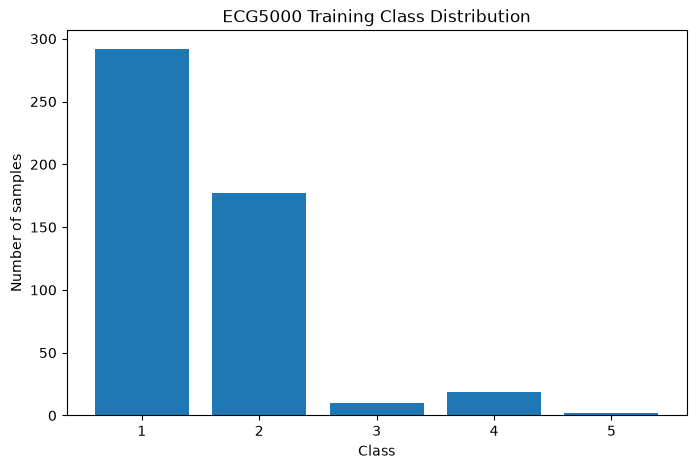

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(classes, counts)

plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("ECG5000 Training Class Distribution")

plt.xticks(classes)

plt.show()


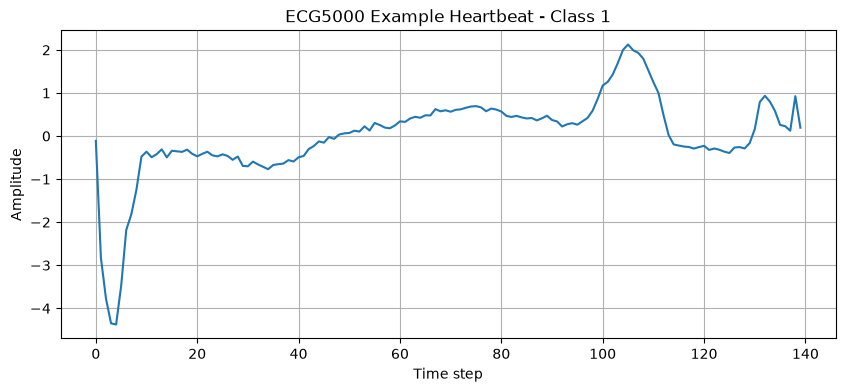

In [12]:
sample_index = 0

plt.figure(figsize=(10, 4))

plt.plot(X_train[sample_index])

plt.xlabel("Time step")
plt.ylabel("Amplitude")
plt.title(
    f"ECG5000 Example Heartbeat - Class {y_train[sample_index]}"
)

plt.grid()

plt.show()

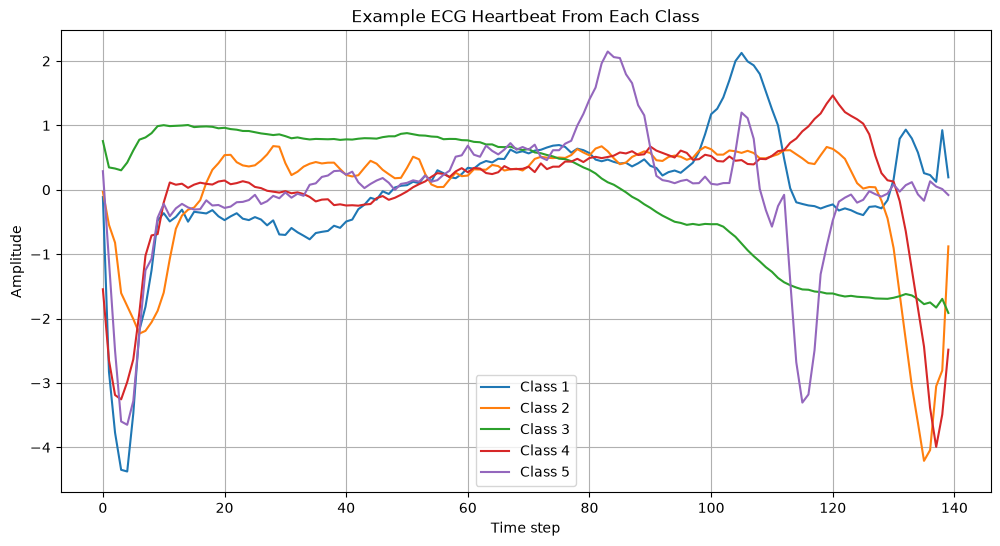

In [13]:
plt.figure(figsize=(12, 6))

for cls in classes:

    # Find all samples belonging to this class
    indices = np.where(y_train == cls)[0]

    # Take first sample
    index = indices[0]

    plt.plot(
        X_train[index],
        label=f"Class {cls}"
    )

plt.xlabel("Time step")
plt.ylabel("Amplitude")
plt.title("Example ECG Heartbeat From Each Class")

plt.legend()
plt.grid()

plt.show()


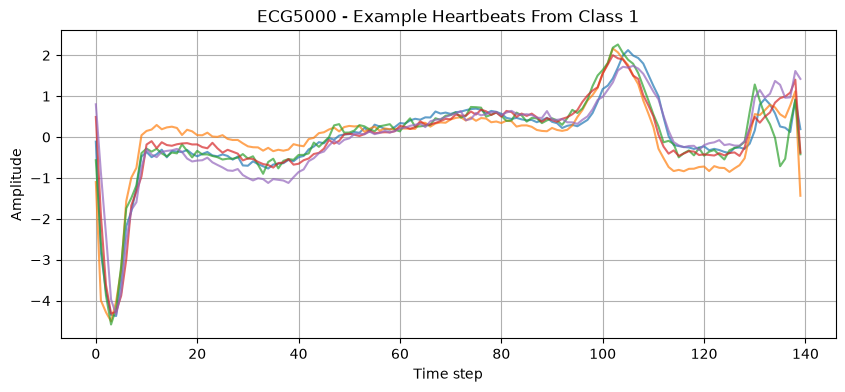

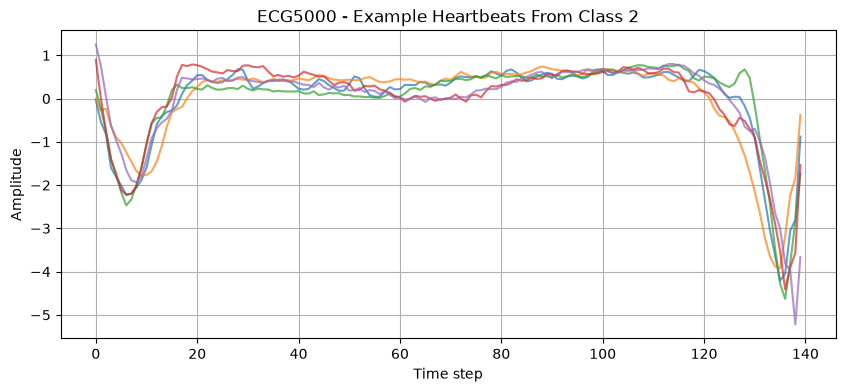

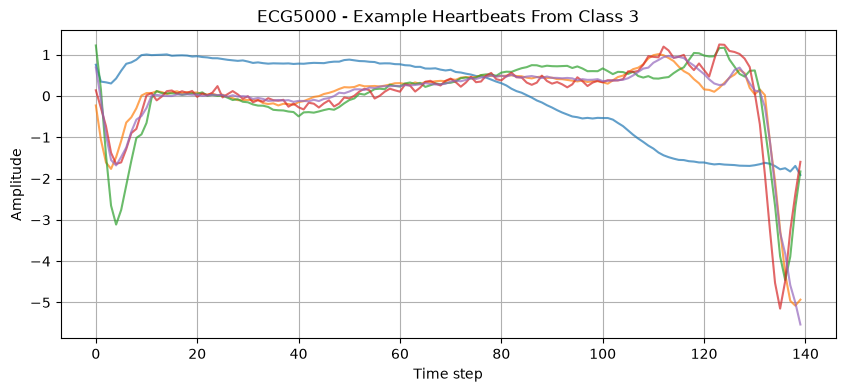

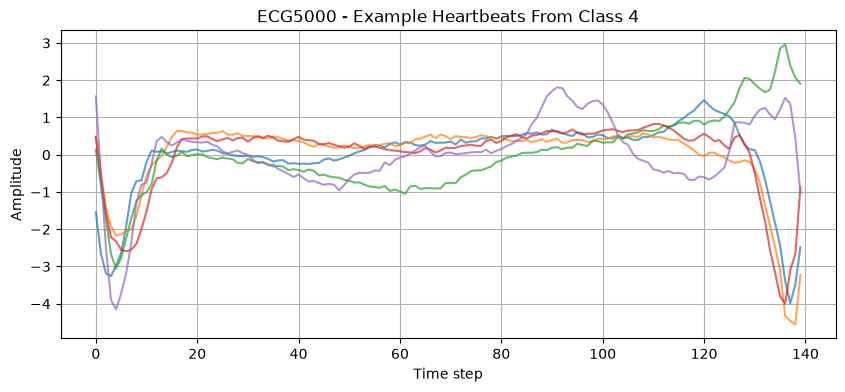

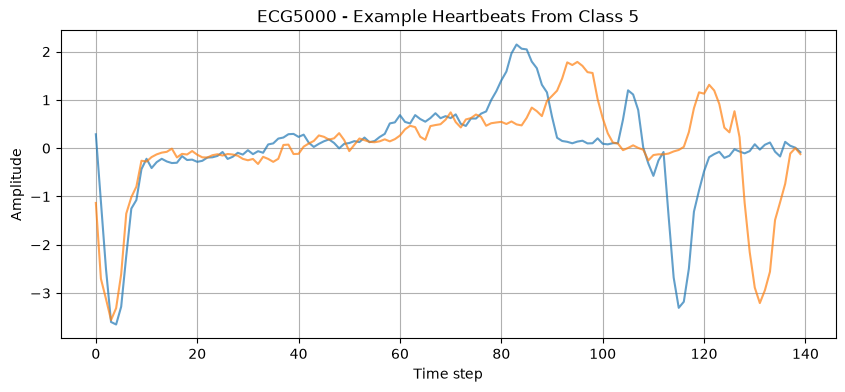

In [14]:
for cls in classes:

    indices = np.where(y_train == cls)[0]

    plt.figure(figsize=(10, 4))

    # Plot up to 5 examples from this class
    for index in indices[:5]:
        plt.plot(
            X_train[index],
            alpha=0.7
        )

    plt.xlabel("Time step")
    plt.ylabel("Amplitude")

    plt.title(
        f"ECG5000 - Example Heartbeats From Class {cls}"
    )

    plt.grid()

    plt.show()